In [4]:
import pandas as pd
import numpy as np
import string
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [5]:
# Download stopwords
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = stopwords.words('english')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [6]:
# Load datasets
fake_df = pd.read_csv("/content/Fake.csv")
true_df = pd.read_csv("/content/True.csv")

In [7]:
# Add labels
fake_df["label"] = 0   # Fake
true_df["label"] = 1   # Real

In [8]:
# Combine datasets
df = pd.concat([fake_df, true_df], axis=0).reset_index(drop=True)
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (44898, 5)


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [9]:
#  Clean text
def clean_text(text):
    text = str(text).lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

In [10]:
# Combine title and text
df['text'] = df['title'] + " " + df['text']
df['text'] = df['text'].apply(clean_text)
df = df.dropna(subset=['text'])
df = df.sample(frac=1).reset_index(drop=True)

In [11]:
# Split data
X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


In [13]:
# function for confusion matrix
def plot_confusion_matrix(cm, model_name):
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()



 Logistic Regression Accuracy: 0.9899777282850779
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4698
           1       0.99      0.99      0.99      4282

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



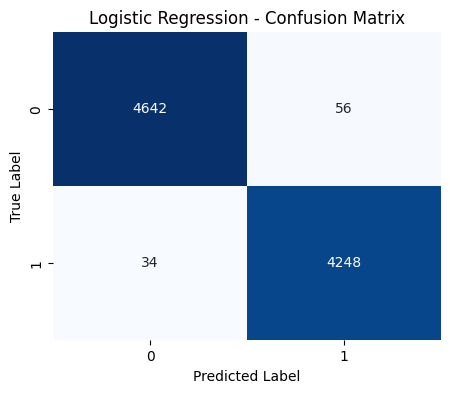

In [14]:
# Logistic Regression Model

lr_model = LogisticRegression()
lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)
print("\n Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
cm_lr = confusion_matrix(y_test, y_pred_lr)
plot_confusion_matrix(cm_lr, "Logistic Regression")


 SVM Accuracy: 0.9944320712694877
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      4698
           1       0.99      1.00      0.99      4282

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



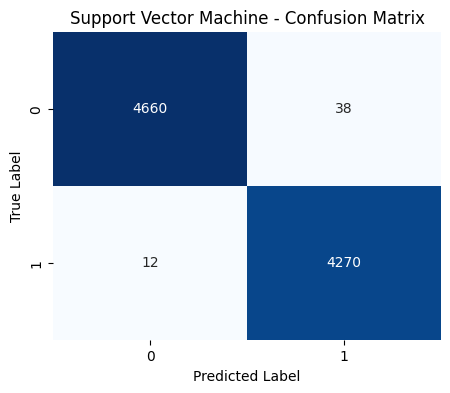

In [15]:
# Support Vector Machine Model

svm_model = SVC(kernel='linear')
svm_model.fit(X_train_tfidf, y_train)
y_pred_svm = svm_model.predict(X_test_tfidf)
print("\n SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))
cm_svm = confusion_matrix(y_test, y_pred_svm)
plot_confusion_matrix(cm_svm, "Support Vector Machine")


 Random Forest Accuracy: 0.9977728285077951
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4698
           1       1.00      1.00      1.00      4282

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



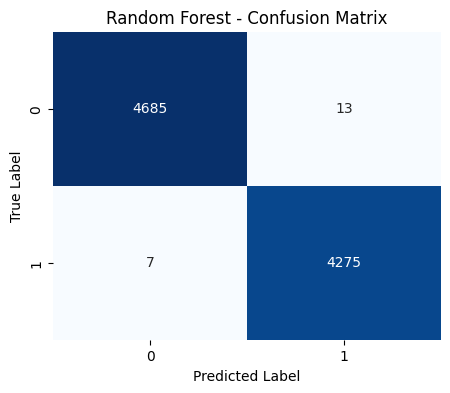

In [16]:
# Random Forest Model

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_tfidf, y_train)
y_pred_rf = rf_model.predict(X_test_tfidf)
print("\n Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
cm_rf = confusion_matrix(y_test, y_pred_rf)
plot_confusion_matrix(cm_rf, "Random Forest")

In [18]:
# Compare all model accuracies
results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "SVM": accuracy_score(y_test, y_pred_svm),
    "Random Forest": accuracy_score(y_test, y_pred_rf)
}

print("\nModel Comparison:")
for model_name, acc in results.items():
    print(f"{model_name}: {acc:.4f}")


Model Comparison:
Logistic Regression: 0.9900
SVM: 0.9944
Random Forest: 0.9978


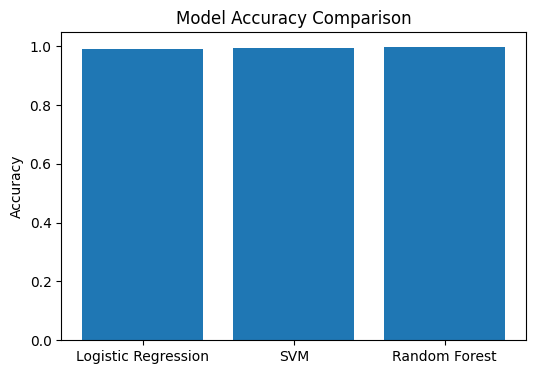

In [19]:
# Bar Chart for Comparison
plt.figure(figsize=(6,4))
plt.bar(results.keys(), results.values())
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()


In [22]:
#  Prediction Function

def predict_news(news_text, model_choice="Logistic Regression"):
    cleaned = clean_text(news_text)
    vectorized = vectorizer.transform([cleaned])

    if model_choice == "Logistic Regression":
        prediction = lr_model.predict(vectorized)[0]
    elif model_choice == "SVM":
        prediction = svm_model.predict(vectorized)[0]
    elif model_choice == "Random Forest":
        prediction = rf_model.predict(vectorized)[0]
    else:
        return "Invalid model name! Choose from Logistic Regression, SVM, or Random Forest."

    return " Real News " if prediction == 1 else " Fake News "

In [24]:
#  User Input

sample = input("\nEnter NEWS To Check Fake or Real: ")
chosen_model = input("Choose Model (Logistic Regression / SVM / Random Forest): ")
print(predict_news(sample, chosen_model))


Enter NEWS To Check Fake or Real: U.S. military to accept transgender recruits on Monday: Pentagon
Choose Model (Logistic Regression / SVM / Random Forest): SVM
 Real News 
